### SKELETAL VARIATION PROJECT
##  Claim: 50% of bones are in the hand and feet. You might have heard the claim that over half of the bones in your body are found in your hands and feet. is this claim true or is it an urban lengend ?

In [1]:
import pandas as pd

In [ ]:
#loanding up a dataset 'adult-human-skeleton.csv'

In [3]:
adult = pd.read_csv('adult-human-skeleton.csv')
print(adult)

                             name region subregion    side  fused_from
0                         frontal   head   cranium  center           2
1                   left parietal   head   cranium    left           1
2                  right parietal   head   cranium   right           1
3                   left temporal   head   cranium    left           1
4                  right temporal   head   cranium   right           1
..                            ...    ...       ...     ...         ...
201  right distal pedal phalanx 1   foot      toes   right           1
202  right distal pedal phalanx 2   foot      toes   right           1
203  right distal pedal phalanx 3   foot      toes   right           1
204  right distal pedal phalanx 4   foot      toes   right           1
205  right distal pedal phalanx 5   foot      toes   right           1

[206 rows x 5 columns]


In [4]:
df = adult
df.describe()

,fused_from
count,206.000000
mean,1.480583
std,0.919762
min,1.000000
25%,1.000000
50%,1.000000
75%,1.750000
max,6.000000


from the analysis above , let us try to use other method to count the bones[region] in each using the value_count ()

In [5]:
df['region'].value_counts()

region
hand     54
foot     52
torso    50
head     28
neck      8
leg       8
arm       6
Name: count, dtype: int64

In [ ]:
# also, from the analysis above , The hands have total number of 54 bones, and the feet have 52 bones. 
# earlier we saw the entire body has 206 bones. let further calaculate what proportion are in the hands and feet.

In [7]:
(54+52)/206

0.5145631067961165

over 51% of bones are found in the hand and feet. The claim is true .
baby bones,
Infant  have more bones than adults, but as the baby develops, group of bones fuse together.

In [8]:
# sort by the 'fused_from' values
# use descending oder

In [9]:
df.sort_values(by='fused_from',ascending=False)

,name,region,subregion,side,fused_from
40,sternum,torso,chest,center,6
30,c2,neck,vertebra,center,5
82,sacrum,torso,pelvis,center,5
5,occipital,head,cranium,center,4
83,coccyx,torso,pelvis,center,4
...,...,...,...,...,...
201,right distal pedal phalanx 1,foot,toes,right,1
202,right distal pedal phalanx 2,foot,toes,right,1
203,right distal pedal phalanx 3,foot,toes,right,1
204,right distal pedal phalanx 4,foot,toes,right,1


In [10]:
# from the analysis above , let us further analyze the level at which human infants bones reduces to adult stage

In [11]:
df["fused_from"].sum()

np.int64(305)

Human infants have [ 305] bones , many of which has fuesd together, resulting in 206 bones in the adult body.
human neck bones.
Neck are quiet flexible . let us further calculate how many bones are in the human neck to allow for that flexibility? let us find where the region is neck.

In [12]:
df.query('region=="neck"')

,name,region,subregion,side,fused_from
28,hyoid,neck,throat,center,3
29,c1,neck,vertebra,center,3
30,c2,neck,vertebra,center,5
31,c3,neck,vertebra,center,3
32,c4,neck,vertebra,center,3
33,c5,neck,vertebra,center,3
34,c6,neck,vertebra,center,3
35,c7,neck,vertebra,center,3


The neck has 1 throat bone, and a stack of (7) neck vertebrae, named c1 through c7. The 'c' stands for carvical, meaning neck.

In [13]:
mammal =pd.read_csv("mammal-neck-bones.csv")
print(mammal)

                 species  neck_vertebrae
0                cheetah               7
1                 impala               7
2            giant panda               7
3             hartebeest               7
4                  moose               7
..                   ...             ...
297               alpaca               7
298        common wombat               7
299              red fox               7
300           fennec fox               7
301  california sea lion               7

[302 rows x 2 columns]


Let us find the data for giraffes, which we know have really long neck

In [14]:
mammal.query('species == "giraffe"')

,species,neck_vertebrae
108,giraffe,7


Despite their very long necks, giraffe also has 7 neck vertebrae!

In [15]:
# From the dataset, let us do a further research where vertebrae does not equal 7.

In [16]:
mammal.query('neck_vertebrae !=7')

,species,neck_vertebrae
27,pale-throated sloth,9
28,brown-throated sloth,9
60,hoffmann's two-toed sloth,6
291,west indian manatee,6


from the above analysis, it looks like the only mammals withiout 7 vertebrae are manatees and sloths which is 6 and 9 vertebrae

In [17]:
# Let us carry a further research on Bird Neck bones.
# Bird seems to have many more neck vertebrae than mammals.
# let us use series.plot.bar() to make quick auto-lableed bar chart of thee value counts to get a sense of distribution

In [18]:
bird = pd.read_csv("bird-neck-bones.csv")
print(bird)

                 species  neck_vertebrae
0      cinereous vulture              13
1             guineafowl              14
2   red-legged partridge              14
3    blue-cheeked parrot              12
4       northern pintail              15
..                   ...             ...
76              barn owl              12
77       eurasian hoopoe              13
78                 murre              13
79  new zealand rockwren              13
80              bushwren              13

[81 rows x 2 columns]


In [19]:
bird_counts = bird['neck_vertebrae'].value_counts()

In [20]:
bird_counts = bird_counts.sort_index()

,species,neck_vertebrae
28,mute swan,23


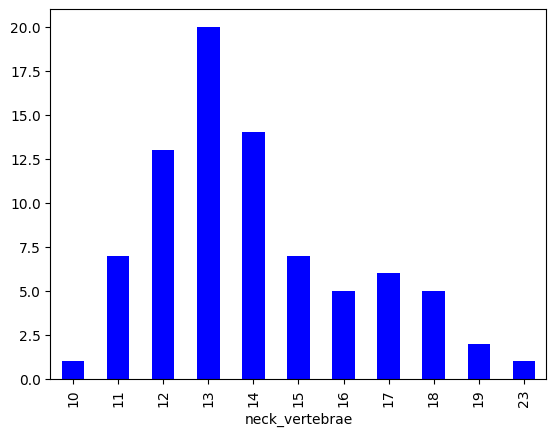

In [21]:
bird_counts.plot.bar(color="blue")
bird.query('neck_vertebrae == neck_vertebrae.max()')